In [66]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
import copy
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [86]:
def load_preprocessed_data():
    """Load preprocessed data from Step 2"""
    data = np.load('data/processed/all_tickers_preprocessed_final.npz')
    scaler = joblib.load('data/processed/all_tickers_scaler_final.pkl')
    metadata = joblib.load('data/processed/all_tickers_metadata_final.pkl')
    return {
        'X_train': data['X_train'],
        'X_val': data['X_val'],
        'X_test': data['X_test'],
        'y_train_reg': data['y_train_reg'],
        'y_val_reg': data['y_val_reg'],
        'y_test_reg': data['y_test_reg'],
        'scaler': scaler,
        'feature_cols': metadata['feature_cols']
    }

# Load data
data_loaded = load_preprocessed_data()

X_train = data_loaded['X_train']
X_val = data_loaded['X_val']
X_test = data_loaded['X_test']
y_train = data_loaded['y_train_reg']
y_val = data_loaded['y_val_reg']
y_test = data_loaded['y_test_reg']
feature_cols = data_loaded['feature_cols']

print(f"✅ Data loaded successfully!")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_val shape: {X_val.shape}")
print(f"  X_test shape: {X_test.shape}")
print(f"  Features: {feature_cols}")

# Combine all data for walk-forward validation
X_all = np.vstack([X_train, X_val, X_test])
y_all = np.concatenate([y_train, y_val, y_test])

✅ Data loaded successfully!
  X_train shape: (180132, 8)
  X_val shape: (38596, 8)
  X_test shape: (38645, 8)
  Features: ['RSI_14', 'MACD_line', 'MACD_signal', 'MACD_histogram', 'BB_width', 'ATR_14', 'OBV', 'MA_Crossover_5_20']


In [88]:
class SequenceDataset(Dataset):
    """Sliding window dataset for LSTM input."""
    
    def __init__(self, features, targets, seq_length=60):
        self.seq_length = seq_length
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(targets, dtype=torch.float32)
    
    def __len__(self):
        return len(self.y) - self.seq_length
    
    def __getitem__(self, idx):
        return (
            self.X[idx : idx + self.seq_length],
            self.y[idx + self.seq_length],
        )

In [90]:
class FinancialLSTM(nn.Module):
    """
    LSTM model for stock return prediction.
    
    Input: (batch_size, seq_length, n_features)
    Output: (batch_size,) - predicted next-day return
    """
    
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True,  # Input shape: (batch, seq, features)
        )
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )
    
    def forward(self, x):
        # x shape: (batch, seq_length, n_features)
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # Use only the LAST time step's output for prediction
        # lstm_out[:, -1, :] shape: (batch, hidden_size)
        last_output = lstm_out[:, -1, :]
        
        return self.fc(last_output).squeeze(-1)

# Create model for testing
input_dim = X_all.shape[1]
model_lstm = FinancialLSTM(
    input_size=input_dim,
    hidden_size=32,
    num_layers=1,
    dropout=0.3
).to(device)

n_params = sum(p.numel() for p in model_lstm.parameters() if p.requires_grad)
print(f"\nLSTM Model Architecture:")
print(model_lstm)
print(f"\nTotal trainable parameters: {n_params:,}")



LSTM Model Architecture:
FinancialLSTM(
  (lstm): LSTM(8, 32, batch_first=True)
  (fc): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total trainable parameters: 6,465


In [92]:
def train_epoch(model, loader, criterion, optimizer, device, max_grad_norm=1.0):
    """Train one epoch with gradient clipping."""
    model.train()
    total_loss = 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = criterion(pred, y)
        loss.backward()
        
        # ── GRADIENT CLIPPING (essential for LSTMs) ──
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
        
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate_model(model, loader, criterion, device):
    """Evaluate model and return loss + metrics."""
    model.eval()
    total_loss = 0
    preds_list, targets_list = [], []
    
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            total_loss += criterion(pred, y).item()
            preds_list.extend(pred.cpu().numpy())
            targets_list.extend(y.cpu().numpy())
    
    preds = np.array(preds_list)
    targets = np.array(targets_list)
    
    mse = total_loss / len(loader)
    direction_acc = np.mean((preds > 0) == (targets > 0))
    
    # Sharpe of long/short strategy
    strategy_returns = np.where(preds > 0, targets, -targets)
    sharpe = (strategy_returns.mean() / strategy_returns.std() * np.sqrt(252)
              if strategy_returns.std() > 0 else 0)
    
    return mse, direction_acc, sharpe, preds, targets

In [94]:
SEQ_LENGTH = 60

# Create datasets
train_seq_dataset = SequenceDataset(X_train, y_train, SEQ_LENGTH)
val_seq_dataset = SequenceDataset(X_val, y_val, SEQ_LENGTH)
test_seq_dataset = SequenceDataset(X_test, y_test, SEQ_LENGTH)

print(f"Sequence datasets created:")
print(f"  Train samples: {len(train_seq_dataset):,}")
print(f"  Val samples: {len(val_seq_dataset):,}")
print(f"  Test samples: {len(test_seq_dataset):,}")

# Create DataLoaders
BATCH_SIZE = 32
train_seq_loader = DataLoader(train_seq_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_seq_loader = DataLoader(val_seq_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_seq_loader = DataLoader(test_seq_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ DataLoaders created with batch_size={BATCH_SIZE}")

# Create fresh model
model_lstm = FinancialLSTM(
    input_size=input_dim,
    hidden_size=64,
    num_layers=2,
    dropout=0.3
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.5
)


MAX_EPOCHS = 50
PATIENCE = 7

best_val_loss = float("inf")
best_model_state = None
wait = 0

train_losses = []
val_losses = []
val_accs = []

for epoch in range(MAX_EPOCHS):
    # Train
    train_loss = train_epoch(model_lstm, train_seq_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    
    # Validate
    val_loss, val_acc, val_sharpe, _, _ = evaluate_model(
        model_lstm, val_seq_loader, criterion, device
    )
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model_lstm.state_dict())
        wait = 0
        marker = " ★"
    else:
        wait += 1
        marker = ""
    
    if (epoch + 1) % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d}/{MAX_EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | Acc: {val_acc:.2%} | LR: {current_lr:.2e}{marker}")
    
    if wait >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Restore best model
if best_model_state:
    model_lstm.load_state_dict(best_model_state)
    print(f"\n✅ Restored best model (val_loss: {best_val_loss:.6f})")


Sequence datasets created:
  Train samples: 180,072
  Val samples: 38,536
  Test samples: 38,585
✅ DataLoaders created with batch_size=32
Epoch  10/50 | Train Loss: 0.000384 | Val Loss: 0.000534 | Acc: 51.70% | LR: 5.00e-04 ★
Early stopping at epoch 17

✅ Restored best model (val_loss: 0.000534)


In [95]:
test_loss, test_acc, test_sharpe, test_preds, test_targets = evaluate_model(
    model_lstm, test_seq_loader, criterion, device
)

In [96]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_mse = mean_squared_error(y_test, lr_preds)
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_acc = np.mean((lr_preds > 0) == (y_test > 0))
lr_returns = np.where(lr_preds > 0, y_test, 0)
lr_sharpe = lr_returns.mean() / lr_returns.std() * np.sqrt(252) if lr_returns.std() > 0 else 0

# --- Feedforward NN Results (from Step 3) ---
# These should be loaded from your saved results
# Using your actual Step 3 results
ff_results = {
    'mse': 0.000298,
    'mae': 0.011640,
    'directional_accuracy': 0.5273,
    'sharpe_ratio': 0.5919
}

print(f"Model Comparison Table:")

comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Feedforward NN', 'LSTM'],
    'MSE': [lr_mse, ff_results['mse'], test_loss],
    'MAE': [lr_mae, ff_results['mae'], mean_absolute_error(test_targets, test_preds)],
    'Directional Accuracy': [lr_acc, ff_results['directional_accuracy'], test_acc],
    'Sharpe Ratio': [lr_sharpe, ff_results['sharpe_ratio'], test_sharpe]
})

print("\n" + comparison_df.to_string(index=False))

print(f"\n Key Findings:")
print(f"  • LSTM vs Linear Regression: {test_acc - lr_acc:+.2%}")
print(f"  • LSTM vs Feedforward NN: {test_acc - ff_results['directional_accuracy']:+.2%}")

Model Comparison Table:

            Model      MSE      MAE  Directional Accuracy  Sharpe Ratio
Linear Regression 0.000303 0.011812              0.500298      0.522250
   Feedforward NN 0.000298 0.011640              0.527300      0.591900
             LSTM 0.000298 0.011645              0.527277      0.590554

 Key Findings:
  • LSTM vs Linear Regression: +2.70%
  • LSTM vs Feedforward NN: -0.00%


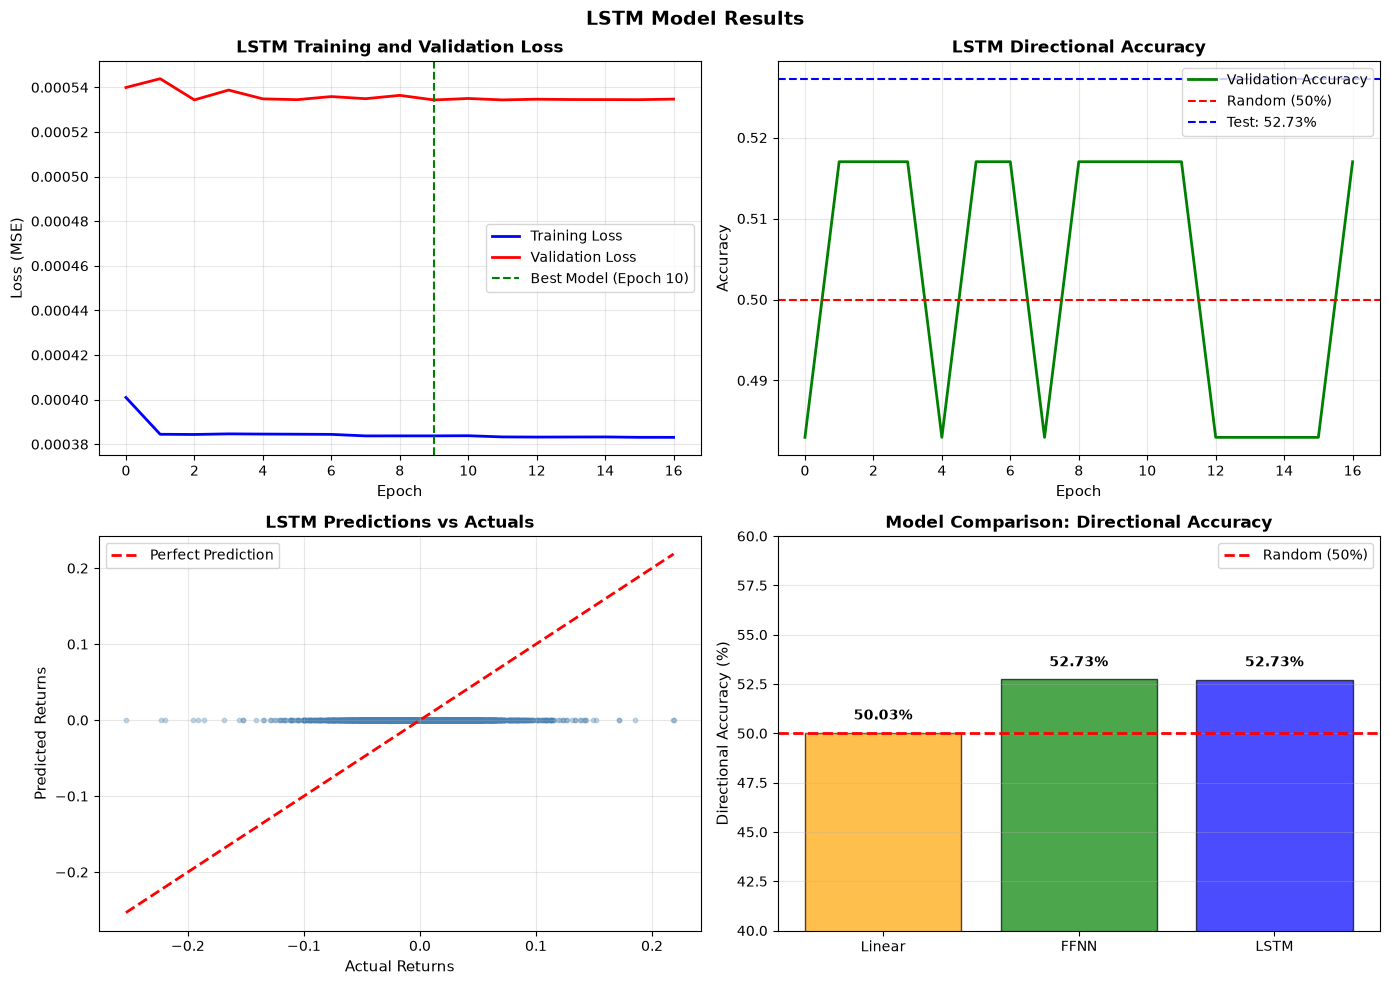


✅ Visualization saved to figures/lstm_results.png


In [100]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LSTM Model Results', fontsize=14, fontweight='bold')

# Plot 1: Loss Curves
axes[0, 0].plot(train_losses, label='Training Loss', color='blue', linewidth=2)
axes[0, 0].plot(val_losses, label='Validation Loss', color='red', linewidth=2)
best_epoch = np.argmin(val_losses)
axes[0, 0].axvline(x=best_epoch, color='green', linestyle='--', 
                   label=f'Best Model (Epoch {best_epoch+1})')
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Loss (MSE)', fontsize=11)
axes[0, 0].set_title('LSTM Training and Validation Loss', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Directional Accuracy
axes[0, 1].plot(val_accs, label='Validation Accuracy', color='green', linewidth=2)
axes[0, 1].axhline(y=0.5, color='red', linestyle='--', label='Random (50%)')
axes[0, 1].axhline(y=test_acc, color='blue', linestyle='--', 
                   label=f'Test: {test_acc:.2%}')
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Accuracy', fontsize=11)
axes[0, 1].set_title('LSTM Directional Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Predictions vs Actuals
axes[1, 0].scatter(test_targets, test_preds, alpha=0.3, s=10, color='steelblue')
axes[1, 0].plot([test_targets.min(), test_targets.max()],
                [test_targets.min(), test_targets.max()],
                'r--', linewidth=2, label='Perfect Prediction')
axes[1, 0].set_xlabel('Actual Returns', fontsize=11)
axes[1, 0].set_ylabel('Predicted Returns', fontsize=11)
axes[1, 0].set_title('LSTM Predictions vs Actuals', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Model Comparison
model_names = ['Linear', 'FFNN', 'LSTM']
accuracies = [lr_acc, ff_results['directional_accuracy'], test_acc]
colors = ['orange', 'green', 'blue']

bars = axes[1, 1].bar(model_names, [a * 100 for a in accuracies], 
                      color=colors, alpha=0.7, edgecolor='black')
axes[1, 1].axhline(y=50, color='red', linestyle='--', label='Random (50%)', linewidth=2)
axes[1, 1].set_ylabel('Directional Accuracy (%)', fontsize=11)
axes[1, 1].set_title('Model Comparison: Directional Accuracy', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].set_ylim(40, 60)

for bar, acc in zip(bars, accuracies):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{acc:.2%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('lstm_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved to figures/lstm_results.png")

In [104]:
def walk_forward_validation(
    features, targets, n_features, seq_length=60,
    n_folds=5, train_months=12, val_months=3,
    device=None, max_epochs=30, patience=5
):
    """
    Walk-forward (expanding window) validation for time-series.
    
    Simulates production deployment:
    - Train on historical data
    - Predict on the next unseen period
    - Expand training window and repeat
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    n_total = len(targets)
    train_size = train_months * 21  # ~21 trading days per month
    val_size = val_months * 21
    step_size = val_size
    
    fold_results = []
    
    for fold in range(n_folds):
        fold_train_end = train_size + fold * step_size
        fold_val_end = fold_train_end + val_size
        
        if fold_val_end > n_total - seq_length:
            break
        
        print(f"\n--- Fold {fold+1} ---")
        print(f"  Train: days 0-{fold_train_end}, Val: days {fold_train_end}-{fold_val_end}")
        
        # Scale features (fit on training only!)
        scaler = StandardScaler()
        train_feats = scaler.fit_transform(features[:fold_train_end])
        val_feats = scaler.transform(features[fold_train_end:fold_val_end])
        
        # Create datasets
        train_ds = SequenceDataset(train_feats, targets[:fold_train_end], seq_length)
        val_ds = SequenceDataset(val_feats, targets[fold_train_end:fold_val_end], seq_length)
        
        if len(train_ds) < 10 or len(val_ds) < 10:
            print("  Skipping (too few samples)")
            continue
        
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
        
        # Fresh model for each fold
        model = FinancialLSTM(
            input_size=n_features,
            hidden_size=64,
            num_layers=2,
            dropout=0.3
        ).to(device)
        
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", patience=3, factor=0.5
        )
        
        # Train with early stopping
        best_val_loss = float("inf")
        best_state = None
        wait = 0
        
        for epoch in range(max_epochs):
            train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc, val_sharpe, _, _ = evaluate_model(model, val_loader, criterion, device)
            scheduler.step(val_loss)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = copy.deepcopy(model.state_dict())
                wait = 0
            else:
                wait += 1
            
            if wait >= patience:
                break
        
        # Restore best and evaluate
        if best_state:
            model.load_state_dict(best_state)
        val_mse, val_acc, val_sharpe, _, _ = evaluate_model(model, val_loader, criterion, device)
        
        print(f"  Val MSE: {val_mse:.6f} | Dir Acc: {val_acc:.4f} | Sharpe: {val_sharpe:.4f}")
        
        fold_results.append({
            "fold": fold + 1,
            "mse": val_mse,
            "direction_acc": val_acc,
            "sharpe": val_sharpe,
        })
    
    return fold_results

# Run walk-forward validation
print("\nRunning walk-forward validation...")
print("This may take a few minutes...")
print("-" * 60)

wf_results = walk_forward_validation(
    X_all, y_all, input_dim,
    seq_length=SEQ_LENGTH,
    n_folds=3,
    train_months=12,
    val_months=3,
    device=device,
    max_epochs=30,
    patience=5
)

# Summary
print("\n" + "="*60)
print("WALK-FORWARD RESULTS SUMMARY")
print("="*60)

if wf_results:
    mses = [r["mse"] for r in wf_results]
    accs = [r["direction_acc"] for r in wf_results]
    sharpes = [r["sharpe"] for r in wf_results]
    
    print(f"\n📊 Walk-Forward Validation Results:")
    print(f"  MSE:           {np.mean(mses):.6f} ± {np.std(mses):.6f}")
    print(f"  Direction Acc: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"  Sharpe Ratio:  {np.mean(sharpes):.4f} ± {np.std(sharpes):.4f}")
    
    print("\nPer-fold results:")
    for r in wf_results:
        print(f"  Fold {r['fold']}: MSE={r['mse']:.6f}, "
              f"Acc={r['direction_acc']:.4f}, Sharpe={r['sharpe']:.4f}")


Running walk-forward validation...
This may take a few minutes...
------------------------------------------------------------

--- Fold 1 ---
  Train: days 0-252, Val: days 252-315
  Skipping (too few samples)

--- Fold 2 ---
  Train: days 0-315, Val: days 315-378
  Skipping (too few samples)

--- Fold 3 ---
  Train: days 0-378, Val: days 378-441
  Skipping (too few samples)

WALK-FORWARD RESULTS SUMMARY
